# Getting Started with Pytorch on your device

## Virtual environments
Why do virtual environments matter?

PyTorch installations can differ by:

* Python version
* CPU vs CUDA build
* dependency versions (numpy, matplotlib, etc.)

A virtual environment gives you an isolated Python + site-packages so:

* your system Python stays clean
* projects don’t fight over dependencies
* **“it works on this machine” becomes reproducible**


**Common options:**

* `venv` (built into Python)
* `conda` (heavier, but good for binary stacks)
  * Anaconda, Inc. “Terms of Service” apply to using Anaconda’s commercial package repositories -> cost implications
  * `conda-forge` is a community-run channel and is commonly used to avoid depending on Anaconda, Inc.’s commercial repository terms. -> Configure conda to use `conda-forge`
* `uv`/`pipx`/`poetry` (workflow tools; still rely on environments)
  * `uv pip <command>` blazing fast drop-in replacement of `pip <command>` for many commands.

## Create and activate a venv
### macOS/Linux

```
python3 -m venv venv
source venv/bin/activate
python -m pip install --upgrade pip
```

### Windows (PowerShell)

```
py -m venv venv
.\venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
```
If `py` is not available, use full path to `python.exe`.

## What is happening here? (Linux view)

```
python3 -m venv .venv
source venv/bin/activate
python -m pip install --upgrade pip
```

`source` is a shell built-in that runs a script in the current shell session, not in a new subprocess.

When a script runs in a new process (e.g., `./script.sh`), any changes it makes to environment variables (like `PATH`, `PYTHONPATH`, ...) disappear when the script finishes.

When you run it with `source` (or the shorthand `.`), the commands execute inside your current shell, so changes persist after the script returns.

## Look at your `venv/bin/activate` script
* `deactivate ()` deactivate function to restore previous state
* `PATH="$VIRTUAL_ENV/"bin":$PATH"; export PATH` add the venv to your `PATH`

## Recap: `$PATH`
`$PATH` is an environment variable that tells your shell where to look for executable programs when you type a command. 
`$PATH` contains an ordered, `:`-separated list of paths.
E.g. if you run `python` your shell searches the directories listed in `$PATH`, **in order**, and runs the first matching executable it finds.

In [ ]:
# prefix command with ! to execute it in shell
!echo $PATH

# Install packages
* `pip install uv`
* `uv pip install <package_name_A> <package_B>`
* `uv pip install -r requirements.txt`

Choose pytorch with support for your compute platofrm
  
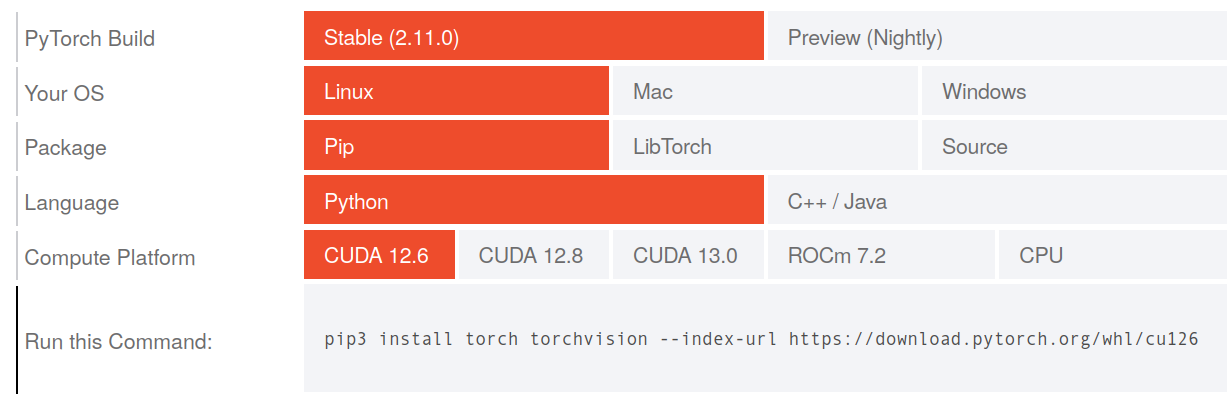

e.g. Cuda 12.4: `uv pip --no-cache install -U torch torchvision --index-url https://download.pytorch.org/whl/cu124`

Note that the CUDA torch wheel is about 10 GB.

Find your cuda version with `nvidia-smi`


# Install packages
* `pip install uv`
* `uv pip install <package_name_A> <package_B>`
* `uv pip install -r requirements.txt`

Choose pytorch with support for your compute platofrm
  
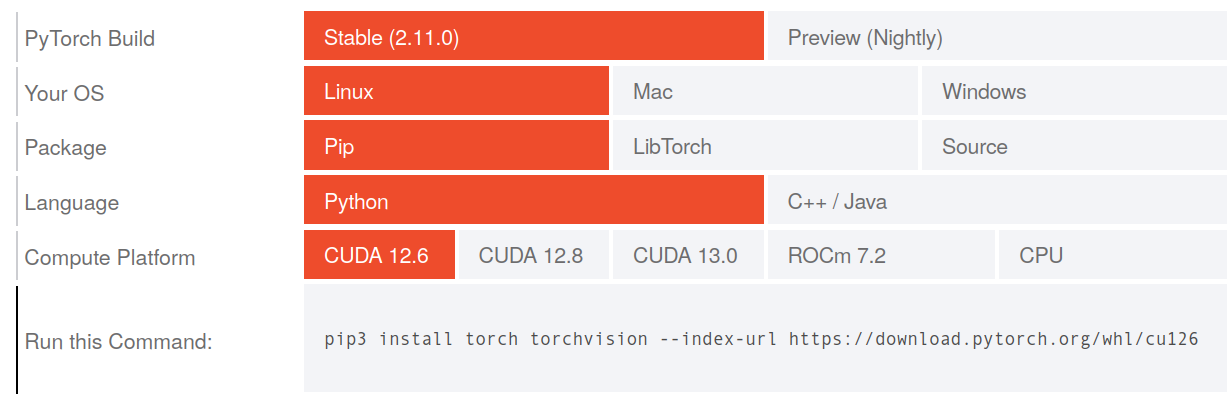

e.g. Cuda 12.4: `uv pip --no-cache install -U torch torchvision --index-url https://download.pytorch.org/whl/cu124`

Note that the CUDA torch wheel is about 10 GB.

Find your cuda version with `nvidia-smi`


## Make your venv available in Jupyter

Venv can be registerd in Jupyter as "kernels"
```
uv pip install jupyter ipykernel
ipython kernel install --user --name my-venv --display-name "My First Python Venv"
```
* List all kernels: `jupyter kernelspec list`
* Remove kernel: `jupyter kernelspec remove <kernel_name>`


## Debugging tips
1. Verify which `python` and `pip` binaries are used: `which python`, `which pip`. They should be in `.../venv/bin`.
2. Verify the path of used packages: `package.__file__`

In [ ]:
import torch
torch.__file__

3. Be cautious about `PYTHON*` environment variables. Especially `PYTHONPATH`.

  `PYTHONPATH` is an environment variable that tells Python to add extra directories to its module search path.

  When you run Python, it builds `sys.path` (the list of places it searches for imports like `import torch`). If `PYTHONPATH` is set, its directories are inserted into `sys.path` (typically near the front), so they get high import priority.

In [ ]:
import sys
sys.path

   Advice: Do not use `PYTHONPATH`.

   Alternative: Package your code and install it editable: `uv pip install -e .`.

   Packaging Python Projects: https://packaging.python.org/en/latest/tutorials/packaging-projects/

4. `uv pip install --exclude-newer 2025-12-24`
   
   You may exploit resolver options of `uv` when trying to reproduce an older setup. E.g. set a cutoff date.
   Dependency requirements often specify only a minimum version, so package managers default to installing the latest available release. However, newer versions may introduce changes that are incompatible with your setup.